# ECG Signal Processing & Heartbeat Classification

**Author:** Thomas Potts  
**Tools:** Python, NumPy, pandas, SciPy, scikit-learn, matplotlib

## Overview

This project applies signal processing and machine learning to electrocardiogram (ECG) data across two parts:

1. **Signal Processing Pipeline** — Load a noisy ECG signal (15,000 samples at 1 kHz), handle missing values, apply FFT-based frequency filtering to remove noise, detect heartbeat peaks using cross-correlation, and compute heart rate over time.
2. **Heartbeat Classification** — Classify 3,841 ECG signal segments into 5 diagnostic categories using KNN, Decision Tree, and Random Forest classifiers with GridSearchCV, achieving up to 88.7% test accuracy.

These techniques, FFT filtering, time-series imputation, cross-correlation, and multi-class classification, are widely applicable to environmental sensor data, remote sensing time series, and other domains where noisy, high-frequency signals require automated analysis.

---
## Part 1: ECG Signal Processing Pipeline

### Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import fft
from scipy.ndimage import correlate

### Step 1: Load and Visualize the Raw Signal

The ECG signal contains 15,000 amplitude samples recorded at 1 kHz (1 ms intervals). The raw signal contains both noise and missing values that need to be addressed before analysis.

In [2]:
data = pd.read_csv('project_ecg_part1_signal_missing_value.csv')
print(f"Shape: {data.shape}")
data.head()

Shape: (15000, 2)


,Amp,t
0,57.000000,0.000
1,532.528258,0.001
2,350.892626,0.002
3,-236.892626,0.003
4,-418.528258,0.004


Sampling interval: 0.001s
Sampling frequency: 1000.0 Hz


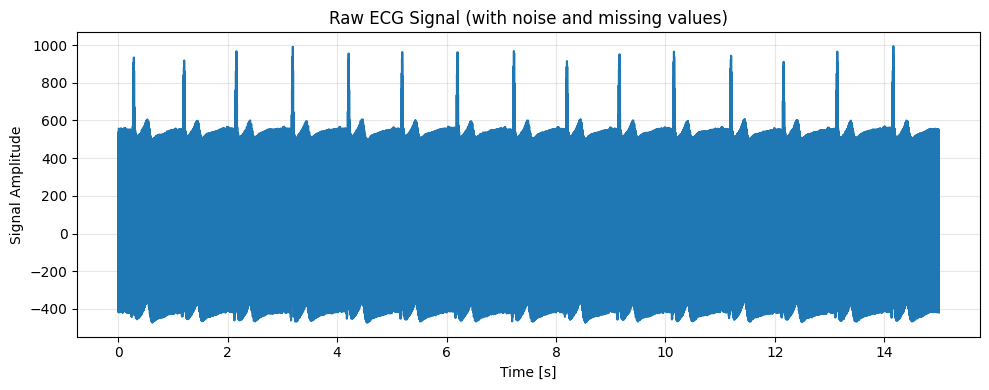

In [3]:
x = data['Amp'].values
t = data['t'].values

dt = np.mean(np.diff(t))
fs = 1 / dt
print(f"Sampling interval: {dt}s")
print(f"Sampling frequency: {fs} Hz")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal Amplitude')
ax.set_title('Raw ECG Signal (with noise and missing values)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 2: Handling Missing Values

The signal contains 5 missing amplitude values. Since this is a time series with smooth underlying structure, linear interpolation is appropriate. It estimates missing points from their temporal neighbors rather than using a global mean.

In [4]:
print(f"Missing values before interpolation: {data.isnull().sum()['Amp']}")

data = data.interpolate(method='linear', axis=0, inplace=False)

print(f"Missing values after interpolation: {data.isnull().sum()['Amp']}")

x = data['Amp'].values

Missing values before interpolation: 5
Missing values after interpolation: 0


### Step 3: Noise Reduction via Fourier Transform

The core idea: transform the signal from the time domain to the frequency domain using FFT, identify and zero out high-frequency noise components (> 100 Hz), then transform back. This preserves the physiologically meaningful low-frequency heartbeat signal while removing electrical noise.

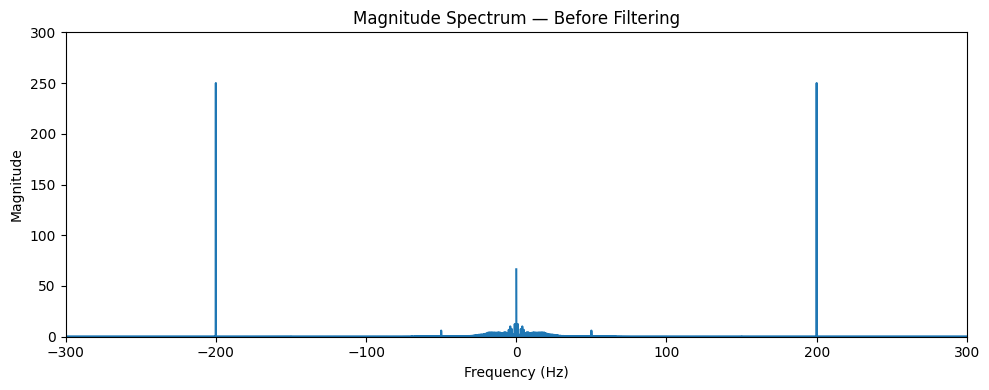

In [5]:
# Transform to frequency domain
X = fft.fft(x)
X_abs = np.abs(X) / len(x)
freqs = fft.fftfreq(len(x), d=dt)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, X_abs)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title('Magnitude Spectrum — Before Filtering')
plt.xlim([-300, 300])
plt.ylim([0, 300])
plt.tight_layout()
plt.show()

The spectrum shows significant energy at high frequencies (beyond ±100 Hz) that corresponds to noise. Zeroing out these components acts as a low-pass filter.

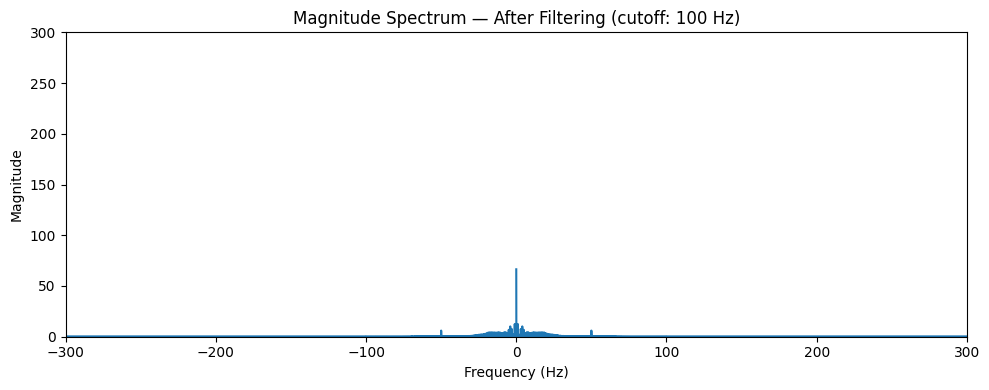

In [6]:
# Zero out high-frequency noise components
X[(freqs < -100) | (freqs > 100)] = 0

# Verify the filtered spectrum
X_abs = np.abs(X) / len(x)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, X_abs)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude')
ax.set_title('Magnitude Spectrum — After Filtering (cutoff: 100 Hz)')
plt.xlim([-300, 300])
plt.ylim([0, 300])
plt.tight_layout()
plt.show()

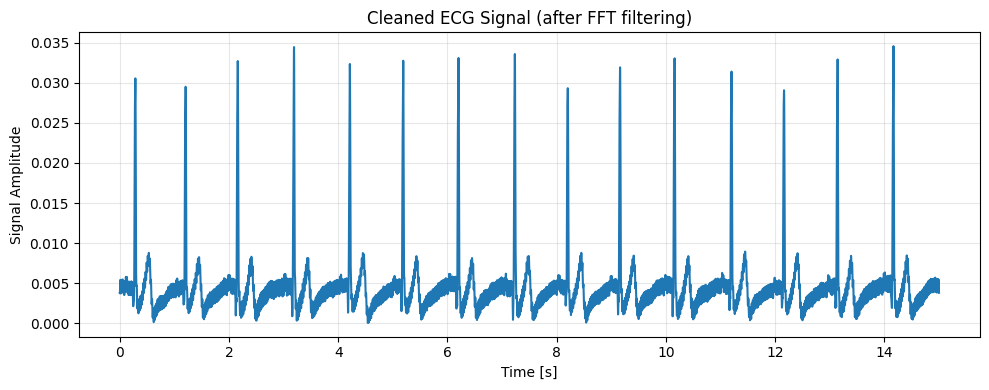

In [7]:
# Inverse FFT to recover the cleaned time-domain signal
X = X / len(x)
x_clean = fft.ifft(X).real

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x_clean)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal Amplitude')
ax.set_title('Cleaned ECG Signal (after FFT filtering)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4: Peak Detection via Cross-Correlation

To detect heartbeat peaks, I use two convolution kernels that identify points where the signal transitions from rising to falling:
- `h1 = [-1, 1, 0]` — detects positive slopes (signal rising)
- `h2 = [0, 1, -1]` — detects negative slopes (signal falling)

A point where both responses are positive is a local peak. R-peaks (the tall, sharp peaks corresponding to heartbeats) are then isolated using a threshold of mean + 2 standard deviations.

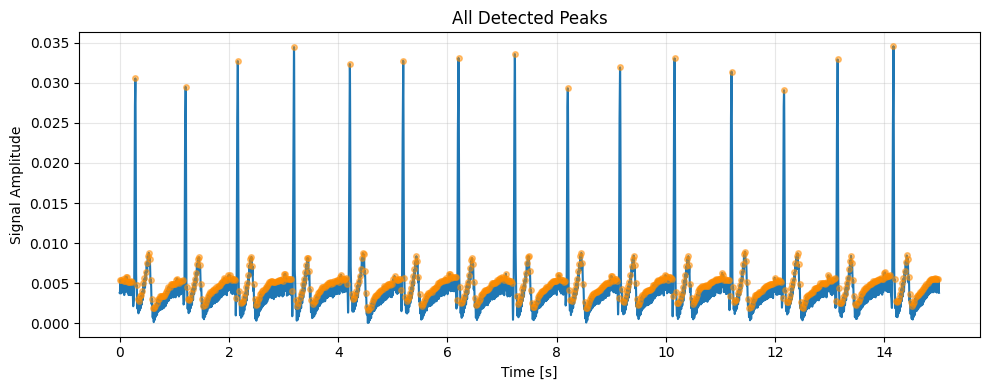

In [8]:
# Cross-correlation to find all peaks
h1 = [-1, 1, 0]
h2 = [0, 1, -1]
y = correlate(x_clean, h1, mode='nearest')
z = correlate(x_clean, h2, mode='nearest')
PeakIndexArray = np.where((y > 0) & (z > 0))[0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x_clean)
ax.plot(t[PeakIndexArray], x_clean[PeakIndexArray], 'o', markersize=4, color='darkorange', alpha=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal Amplitude')
ax.set_title('All Detected Peaks')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

R-peak threshold: 0.0136
R-peaks detected: 15


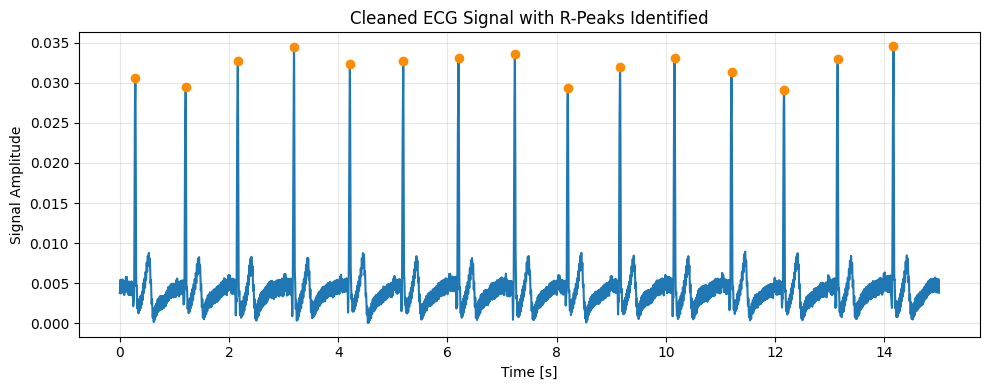

In [9]:
# Isolate R-peaks using threshold
peak_values = x_clean[PeakIndexArray]
mean = np.mean(peak_values)
std = np.std(peak_values)
threshold = mean + (2 * std)
print(f"R-peak threshold: {threshold:.4f}")

RPeakIndexArray = PeakIndexArray[peak_values > threshold]
print(f"R-peaks detected: {len(RPeakIndexArray)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, x_clean)
ax.plot(t[RPeakIndexArray], x_clean[RPeakIndexArray], 'o', markersize=6, color='darkorange')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal Amplitude')
ax.set_title('Cleaned ECG Signal with R-Peaks Identified')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 5: Heart Rate Calculation

Heart rate is derived from the interval between consecutive R-peaks:

$$\text{Heart Rate (bpm)} = \frac{60 \times f_s}{\text{R-peak interval (samples)}}$$

This produces a beat-by-beat heart rate estimate over the duration of the recording.

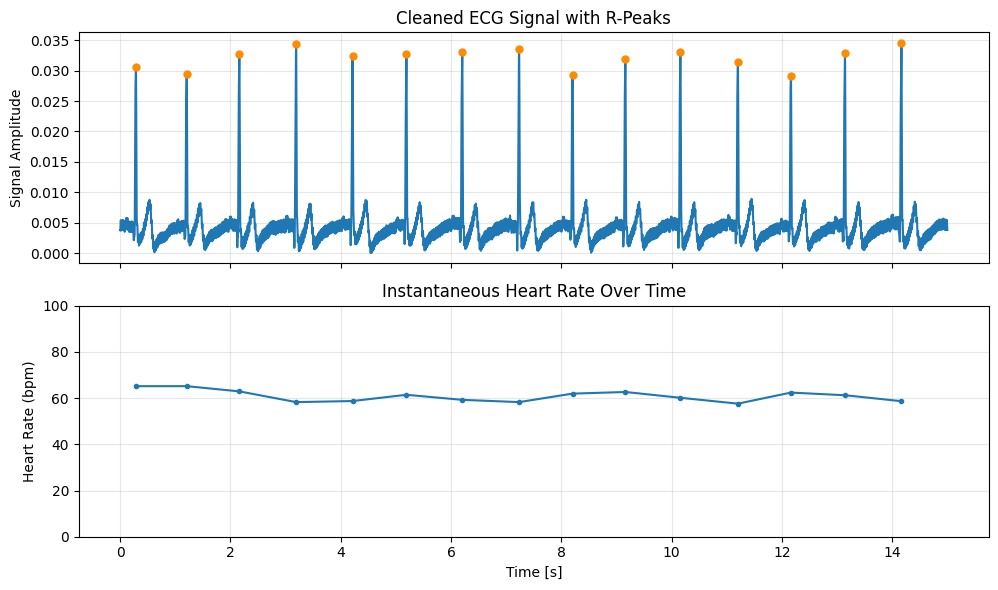

Average heart rate: 60.9 bpm
Heart rate range: 57.6 - 65.1 bpm


In [10]:
HeartRate = np.zeros(RPeakIndexArray.shape[0])

for n in range(1, RPeakIndexArray.shape[0]):
    HeartRate[n] = 60 * fs / (RPeakIndexArray[n] - RPeakIndexArray[n-1])

HeartRate[0] = HeartRate[1]

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(t, x_clean)
ax[0].plot(t[RPeakIndexArray], x_clean[RPeakIndexArray], 'o', markersize=5, color='darkorange')
ax[0].set_ylabel('Signal Amplitude')
ax[0].set_title('Cleaned ECG Signal with R-Peaks')
ax[0].grid(True, alpha=0.3)

ax[1].plot(t[RPeakIndexArray], HeartRate, '-o', markersize=3)
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Heart Rate (bpm)')
ax[1].set_title('Instantaneous Heart Rate Over Time')
ax[1].set_ylim([0, 100])
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average heart rate: {np.mean(HeartRate):.1f} bpm")
print(f"Heart rate range: {np.min(HeartRate):.1f} - {np.max(HeartRate):.1f} bpm")

---
## Part 2: ECG Heartbeat Classification

In this section, I classify pre-segmented ECG heartbeat signals into 5 diagnostic categories using three classifiers optimized with GridSearchCV. The dataset contains 3,841 heartbeat segments, each with 187 time-series features sampled at 125 Hz.

### Setup

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from time import time

fs_ecg = 125  # sampling frequency for classification data
Ts = 1 / fs_ecg
N = 187  # timepoints per segment
Duration = N * Ts
t_ecg = np.linspace(0, Duration - Ts, N)

### Loading and Exploring the Dataset

In [12]:
X = pd.read_csv('ECG_dataX.csv').values
Y = pd.read_csv('ECG_dataY.csv').values.reshape(-1)

print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]} features")
print(f"Labels: {len(Y)} samples, {len(np.unique(Y))} classes (0-4)")
print(f"Value range: [{X.min()}, {X.max()}] — already normalized, no scaling needed")

Feature matrix: 3841 samples x 187 features
Labels: 3841 samples, 5 classes (0-4)
Value range: [0.0, 1.0] — already normalized, no scaling needed


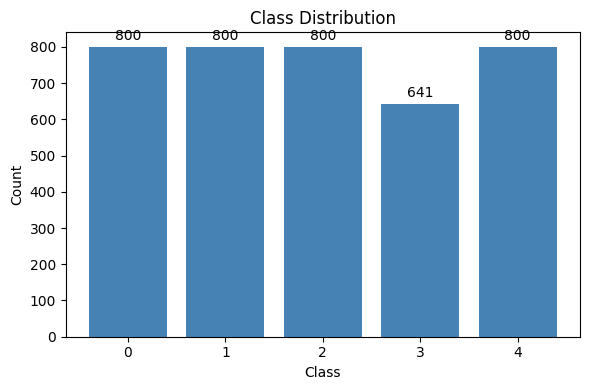

In [13]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
classes, counts = np.unique(Y, return_counts=True)
ax.bar(classes, counts, color='steelblue')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for c, cnt in zip(classes, counts):
    ax.text(c, cnt + 20, str(cnt), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Visualizing Sample Heartbeats by Class

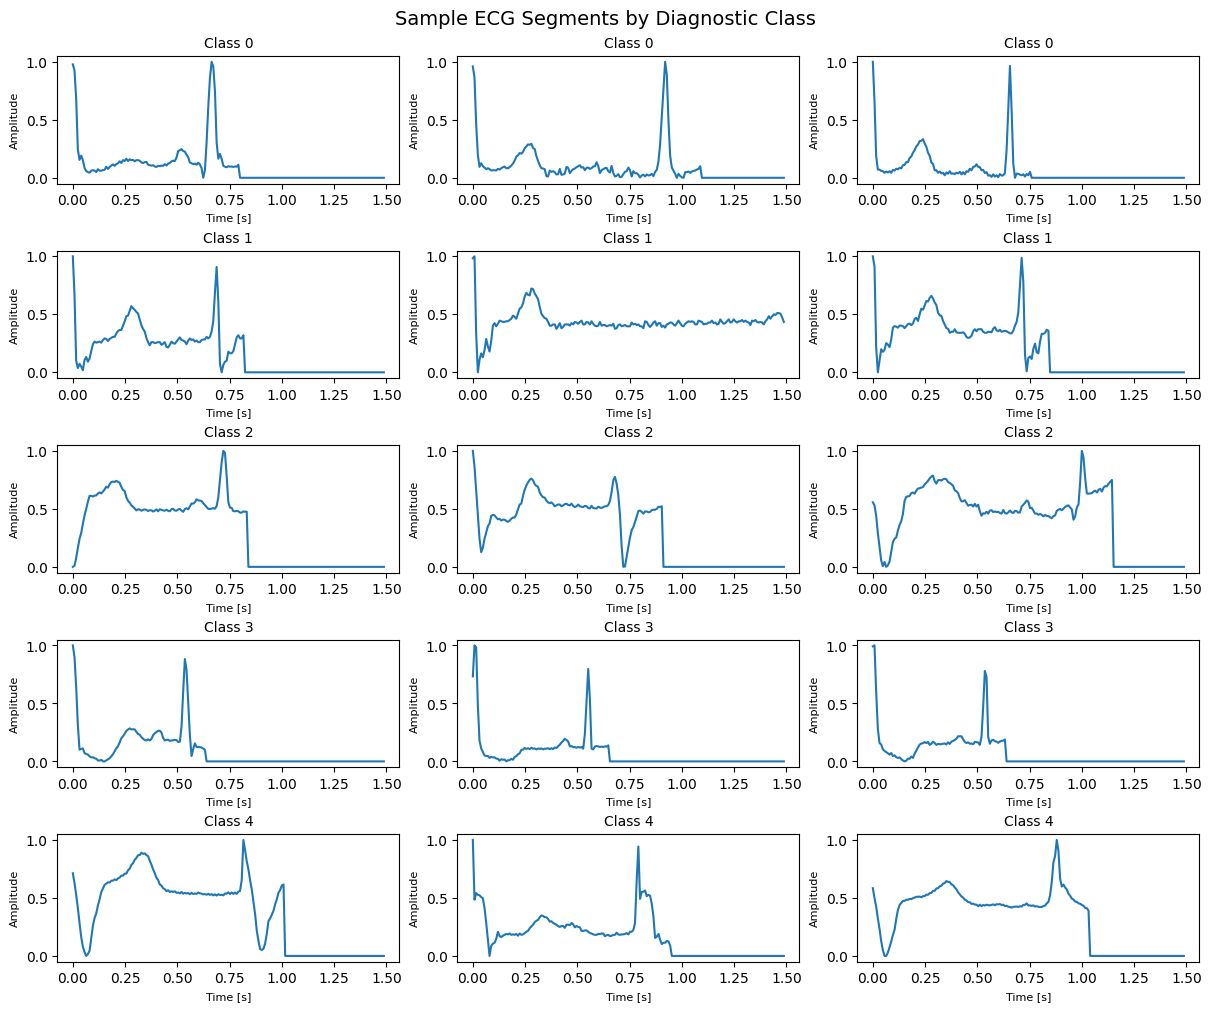

In [14]:
classes = np.unique(Y)

fig, axes = plt.subplots(5, 3, figsize=(12, 10), constrained_layout=True)
for i, c in enumerate(classes):
    class_indices = np.where(Y == c)[0][:3]
    for j, idx in enumerate(class_indices):
        axes[i, j].plot(t_ecg, X[idx])
        axes[i, j].set_title(f'Class {int(c)}', fontsize=10)
        axes[i, j].set_xlabel('Time [s]', fontsize=8)
        axes[i, j].set_ylabel('Amplitude', fontsize=8)
plt.suptitle('Sample ECG Segments by Diagnostic Class', fontsize=14)
plt.show()

### Train/Test Split

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test:     {X_test.shape[0]} samples")

Training: 3072 samples
Test:     769 samples


### KNN Classifier

Tuning `n_neighbors` with 5-fold cross-validation using accuracy as the scoring metric.

In [16]:
n_list = np.arange(1, 100, 5)
param_grid = {'n_neighbors': n_list}

gs_KNN = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

start_time = time()
gs_KNN.fit(X_train, Y_train)
end_time = time()
KNN_time = end_time - start_time

KNN_model_best = gs_KNN.best_estimator_
KNN_train_accuracy = KNN_model_best.score(X_train, Y_train)
KNN_test_accuracy = KNN_model_best.score(X_test, Y_test)

print(f"Best n_neighbors: {gs_KNN.best_params_['n_neighbors']}")
print(f"GridSearchCV time: {KNN_time:.2f}s")
print(f"Training accuracy: {KNN_train_accuracy:.4f}")
print(f"Test accuracy:     {KNN_test_accuracy:.4f}")

Best n_neighbors: 1
GridSearchCV time: 7.11s
Training accuracy: 1.0000
Test accuracy:     0.8817


### Decision Tree Classifier

Tuning `max_depth` to balance model complexity and generalization.

In [17]:
max_depth_list = np.arange(1, 100, 5)
param_grid = {'max_depth': max_depth_list, 'random_state': [0]}

gs_DT = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

start_time = time()
gs_DT.fit(X_train, Y_train)
end_time = time()
DT_time = end_time - start_time

DT_model_best = gs_DT.best_estimator_
DT_train_accuracy = DT_model_best.score(X_train, Y_train)
DT_test_accuracy = DT_model_best.score(X_test, Y_test)

print(f"Best max_depth: {gs_DT.best_params_['max_depth']}")
print(f"GridSearchCV time: {DT_time:.2f}s")
print(f"Training accuracy: {DT_train_accuracy:.4f}")
print(f"Test accuracy:     {DT_test_accuracy:.4f}")

Best max_depth: 11
GridSearchCV time: 56.80s
Training accuracy: 0.9681
Test accuracy:     0.8427


### Random Forest Classifier

Tuning `max_depth` with an ensemble of 10 trees to reduce variance compared to a single decision tree.

In [18]:
param_grid = {
    'max_depth': np.arange(1, 100, 5),
    'n_estimators': [10],
    'random_state': [0]
}

gs_RF = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5
)

start_time = time()
gs_RF.fit(X_train, Y_train)
end_time = time()
RF_time = end_time - start_time

RF_model_best = gs_RF.best_estimator_
RF_train_accuracy = RF_model_best.score(X_train, Y_train)
RF_test_accuracy = RF_model_best.score(X_test, Y_test)

print(f"Best params: {gs_RF.best_params_}")
print(f"GridSearchCV time: {RF_time:.2f}s")
print(f"Training accuracy: {RF_train_accuracy:.4f}")
print(f"Test accuracy:     {RF_test_accuracy:.4f}")

Best params: {'max_depth': np.int64(26), 'n_estimators': 10, 'random_state': 0}
GridSearchCV time: 30.96s
Training accuracy: 0.9938
Test accuracy:     0.8869


### Classification Results Summary

In [19]:
results = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'GridSearchCV Time (s)': [KNN_time, DT_time, RF_time],
    'Training Accuracy': [KNN_train_accuracy, DT_train_accuracy, RF_train_accuracy],
    'Test Accuracy': [KNN_test_accuracy, DT_test_accuracy, RF_test_accuracy]
})
results.style.format({
    'GridSearchCV Time (s)': '{:.2f}',
    'Training Accuracy': '{:.4f}',
    'Test Accuracy': '{:.4f}'
})

,Model,GridSearchCV Time (s),Training Accuracy,Test Accuracy
0,KNN,7.11,1.0000,0.8817
1,Decision Tree,56.80,0.9681,0.8427
2,Random Forest,30.96,0.9938,0.8869


---
## Conclusion

**Signal Processing (Part 1):**
- FFT-based low-pass filtering effectively removed high-frequency noise while preserving the underlying ECG waveform
- Cross-correlation peak detection with threshold-based R-peak isolation provided robust heartbeat identification across the full 15-second recording
- The derived heart rate signal shows physiologically plausible values

**Classification (Part 2):**
- Random Forest achieved the highest test accuracy among the three classifiers, with KNN performing comparably
- Decision Tree showed a larger gap between training and test accuracy, suggesting overfitting despite depth tuning
- KNN with k=1 achieved perfect training accuracy (expected for 1-nearest-neighbor) but still generalized reasonably to the test set

**Transferable techniques:** The signal processing methods used here, FFT filtering, time-series interpolation, peak detection, and multi-class classification on high-dimensional time-series features, are directly applicable to environmental sensor data such as water quality monitors, acoustic ecology recordings, and satellite-derived spectral time series.